In [19]:
import pandas as pd
from matplotlib.figure import Figure

df = pd.read_csv("../src_data/cross_ind_unfiltered_comparison.csv")
df

,runname,seed,steps,agg_score,commonsense_qa/acc,commonsense_qa/acc_norm,hellaswag/acc,hellaswag/acc_norm,openbookqa/acc,openbookqa/acc_norm,...,siqa/acc,siqa/acc_norm,winogrande/acc,winogrande/acc_norm,sciq/acc,sciq/acc_norm,arc/acc,arc/acc_norm,mmlu/acc,mmlu/acc_norm
0,big-run-sampled_full_filtered_no_dedup,6,0,0.330893,0.186,0.233,0.272,0.258,0.166,0.286,...,0.367,0.362,0.516,0.497,0.209,0.202,0.2195,0.2510,0.230294,0.250147
1,big-run-sampled_full_filtered_no_dedup,6,1000,0.360520,0.254,0.260,0.290,0.281,0.138,0.256,...,0.362,0.400,0.517,0.524,0.573,0.515,0.2675,0.2895,0.239489,0.251660
2,big-run-sampled_full_filtered_no_dedup,6,2000,0.373315,0.285,0.278,0.315,0.323,0.138,0.272,...,0.365,0.395,0.509,0.490,0.677,0.596,0.3075,0.3235,0.250318,0.261019
3,big-run-sampled_full_filtered_no_dedup,6,3000,0.388201,0.294,0.291,0.327,0.341,0.152,0.298,...,0.371,0.396,0.512,0.504,0.712,0.621,0.3220,0.3390,0.255646,0.266605
4,big-run-sampled_full_filtered_no_dedup,6,4000,0.393412,0.306,0.307,0.337,0.360,0.172,0.284,...,0.380,0.402,0.522,0.510,0.729,0.612,0.3100,0.3385,0.253048,0.266798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,big-run-sampled_full_ind_minhash,6,163000,0.481842,0.427,0.393,0.488,0.579,0.242,0.358,...,0.420,0.397,0.587,0.568,0.885,0.809,0.4760,0.4595,0.305843,0.330238
671,big-run-sampled_full_ind_minhash,6,164000,0.482727,0.426,0.394,0.487,0.582,0.238,0.360,...,0.422,0.398,0.575,0.562,0.885,0.827,0.4745,0.4625,0.307377,0.332317
672,big-run-sampled_full_ind_minhash,6,165000,0.482413,0.423,0.397,0.482,0.573,0.238,0.360,...,0.409,0.396,0.581,0.569,0.889,0.829,0.4675,0.4600,0.308059,0.331304
673,big-run-sampled_full_ind_minhash,6,166000,0.482014,0.422,0.391,0.477,0.573,0.230,0.358,...,0.420,0.400,0.586,0.566,0.883,0.817,0.4660,0.4645,0.304975,0.329611


In [20]:
runs_mapping = {
    "big-run-refinedweb": "RefinedWeb",
    "big-run-fineweb-cross-dedup-fixed": "FineWeb full MinHash",
    "big-run-sampled_full_ind_minhash": "FineWeb independent MinHash",
    "big-run-sampled_full_filtered_no_dedup": "FineWeb filtered only"
}

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


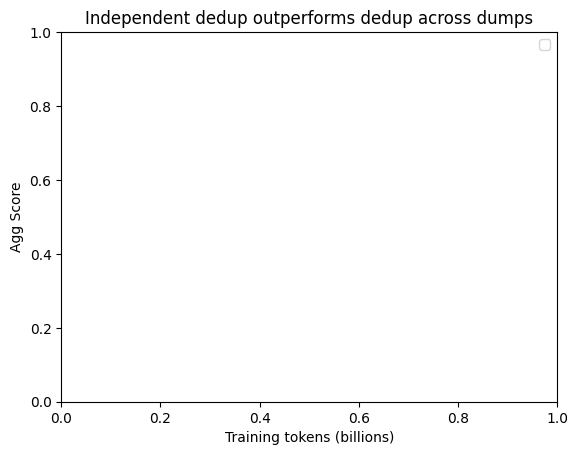

In [21]:
from matplotlib import pyplot as plt

import json
import os
from matplotlib import pyplot as plt
metrics = ['agg_score', 'commonsense_qa/acc_norm', 'hellaswag/acc_norm', 'openbookqa/acc_norm', 'piqa/acc_norm',
                   'siqa/acc_norm', 'winogrande/acc_norm', 'arc/acc_norm', 'mmlu/acc_norm']

def normalize_runname(runname):
    return runname.replace("/", "_")

grouped = (
    df.groupby(["runname", "steps"])
    .agg(
        {
            key: "mean" for key in metrics
        }
    )
    .reset_index()
)

file_id="../assets/data/plots/ind_dedup_better"
files = {}
for metric in metrics:
    datas = {}
    for name, group in grouped.groupby("runname"):
        group = group[["steps", metric]].sort_values(by="steps")
        group = group.set_index("steps")
        rolling_avg = group
        # rolling_avg = group.rolling(wjjjjjjjjjjjjjindow=5).mean()
        datas[name] = {
            "x": (rolling_avg.index * 2048 * 1024 * 1e-9).tolist(),
            "y": rolling_avg[metric].tolist(),
            "label": runs_mapping[name],
        }
    # Sort the datata based on the steps
    datas = {k: v for k, v in sorted(datas.items(), key=lambda x: -x[1]["y"][-1])}
    # Create a folder
    os.makedirs(f"{file_id}", exist_ok=True)
    with open(f"{file_id}/{normalize_runname(metric)}.json", "w") as f:
        json.dump({
            "data": datas,
            "layout": {
                "title": {
                    "text": "Independent dedup outperforms dedup across dumps"
                },
            }
        }, f)
    files[metric] = {"file": f"{normalize_runname(metric)}.json"}
# Create index
with open(f"{file_id}/index.json", "w") as f:
    json.dump({
        "files": files,
        "settings": {
            "defaultMetric": "agg_score",
            "slider":{"min":0,"max":30,"default":5}
        }
    }, f)
        

    
# Add labels and legend
plt.xlabel('Training tokens (billions)')
plt.ylabel('Agg Score')
plt.title('Independent dedup outperforms dedup across dumps')
plt.legend()

# Show the plot
plt.show()